In [1]:
%load_ext autoreload
%autoreload 2
import torch 
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.manifold import Isomap, SpectralEmbedding
from finsler_embedding.experiment_run import *
from finsler_embedding.disbm import *

/home/tblanchard/phd/Finsler-Embedding/.venv/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


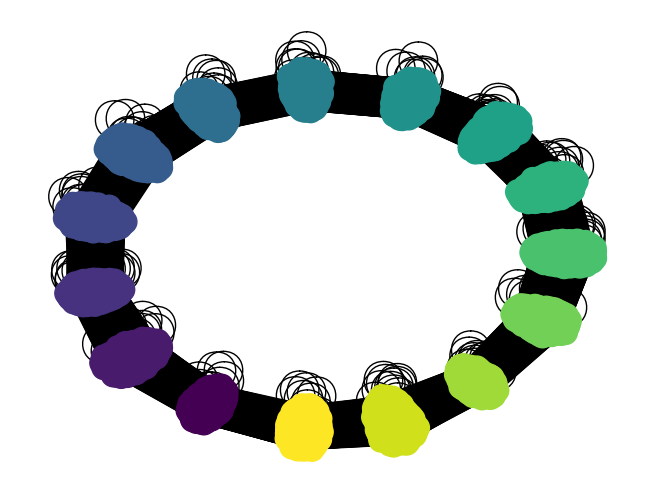

In [2]:
N, K = 2000, 15
r = 0.1
p = 0.4
q = 1 - p - r

edges, dst_edges, community_labels, A = graph_info(p,q,r,K,N)
graph = nx.from_numpy_array(A.numpy())
nx.draw(graph, with_labels=False, node_color=community_labels.numpy(), cmap=plt.cm.viridis)

In [4]:
cfg = ExperimentConfig(
    N=N,
    m=2,
    beta=0.5,
    K=400,
    n_neighbors=10,
    omega_type="random", # Not used here
    function_type="mexican",
    # function_type="coordinates",
    device="cpu",
    export_path=None,
)

In [5]:
epsilon = 1

W, mu_0, mu_1 = gaussian_kernel(edges, dst_edges, epsilon, cfg.N, cfg.m)
c_km = -mu_1 / mu_0 * (cfg.m + 1) / cfg.m

Q_inv_theta = get_Q_inv_theta(W, theta=1)
W_theta_s, W_theta_a = get_W_thetas(W, Q_inv_theta)
P_theta_s, P_theta_a = construct_P_thetas(W_theta_s, W_theta_a)
L_theta_s = 1 / epsilon**2 * P_theta_s
L_theta_a = 1 / epsilon * P_theta_a

In [6]:
# eigenvalues, eigenvectors = torch.linalg.eigh(L_theta_s)
# K = 2
# X_low = eigenvectors[:, :K]

X_low = SpectralEmbedding(n_components=2, affinity='precomputed').fit_transform(W_theta_s.detach().cpu().numpy())
X_low = torch.from_numpy(X_low).float().to(cfg.device)


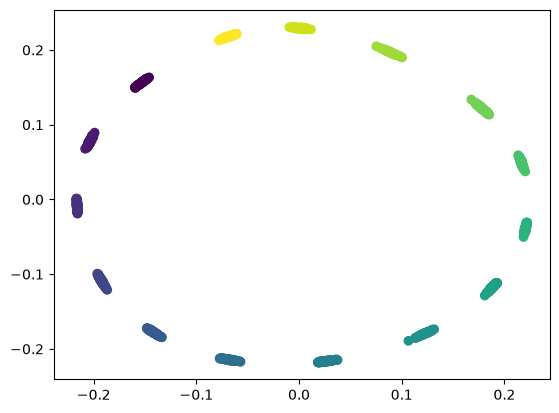

In [9]:
plt.scatter(X_low[:, 0], X_low[:, 1], c=community_labels.numpy(), cmap=plt.cm.viridis)  

In [7]:
base_cometric = IdentityCoMetric()
# base_cometric = CentroidsCometric(centroids=X_low,cometric_centroids=base_cometric(X_low))

In [8]:
m=2
c_2, C, kappa = randers_constants(m, "gaussian")
Gamma = carre_du_champ(L_theta_s, X_low)
V = L_theta_a @ X_low
Gamma_pinv = truncated_pinv(Gamma, rank=m)
c_norm_sq = kappa * torch.einsum("nij,ni,nj->n", Gamma_pinv, V, V)
admissible = c_norm_sq < 1.0 / (m + 3)

c_tilde = (kappa ** 0.5) * V
H_tilde_inv = Gamma - (m + 2) * kappa * torch.einsum("ni,nj->nij", V, V)
H_tilde = truncated_pinv(H_tilde_inv, rank=m)
lambda_tilde = 1.0 - torch.einsum("nij,ni,nj->n", H_tilde, c_tilde, c_tilde)

V_norm = V / (c_norm_sq.sqrt() + 1e-12).unsqueeze(1)
unit_V = V / (V.norm(dim=1, keepdim=True) + 1e-12)

Number of non admissible points: 0


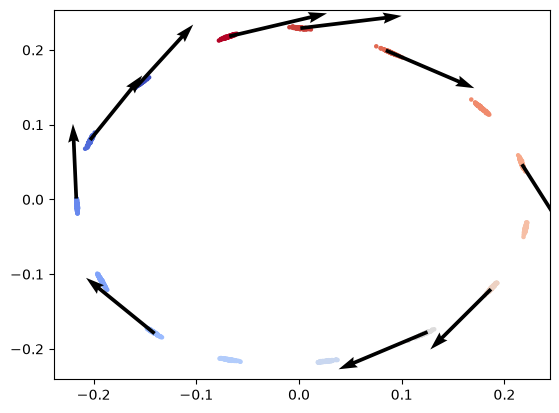

In [17]:
# Sort by x coords
idx = torch.argsort(X_low[:, 0])
X_low_plt = X_low[idx].clone()
unit_V_plt = unit_V[idx].clone()
print(f"Number of non admissible points: {(~admissible).sum()}")
cbar = plt.scatter(
    X_low[:, 0], X_low[:, 1], c=community_labels.numpy(), cmap="coolwarm",s=5
)
skip=200
plt.quiver(
    X_low_plt[::skip, 0],
    X_low_plt[::skip, 1],
    unit_V_plt[::skip, 0],
    unit_V_plt[::skip, 1],
    color="black",
    scale=10,
    angles="xy",
    scale_units="xy",
)
# plt.colorbar(cbar, label="logdet(Gamma)")

  0%|          | 0/1000 [00:00<?, ?it/s]

Loss: 0.0000: 100%|██████████| 1000/1000 [00:02<00:00, 461.29it/s]


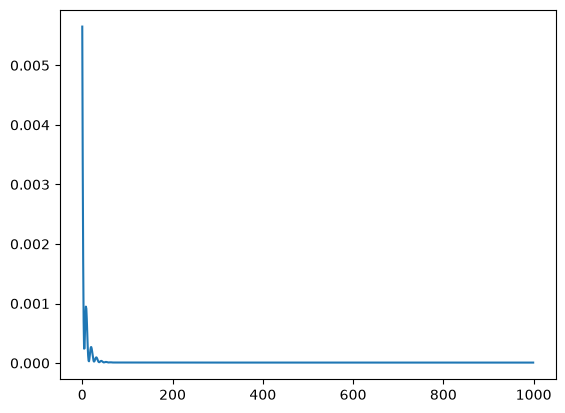

In [27]:
V.shape
from torchvision.ops import MLP
# Train a NN to interpolate V
model = MLP(in_channels=2, hidden_channels=[64, 64,2])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

loss_list = []
pbar = tqdm(range(1000))
for epoch in pbar:
    optimizer.zero_grad()
    V_pred = model(X_low)
    loss = torch.nn.functional.mse_loss(V_pred, V)
    loss.backward()
    optimizer.step()
    pbar.set_description(f"Loss: {loss.item():.4f}")
    loss_list.append(loss.item())
plt.plot(loss_list)

In [40]:
bounds = get_bounds(X_low,margin=0.1)
bounds

tensor([-0.2608,  0.2705, -0.2633,  0.2807])

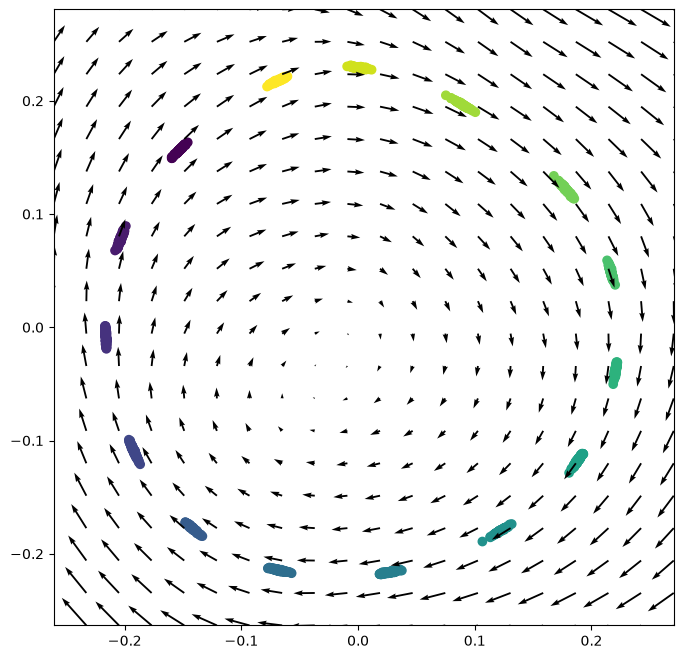

In [48]:
# Grid
x = torch.linspace(bounds[0], bounds[1], 20)
y = torch.linspace(bounds[2], bounds[3], 20)
X, Y = torch.meshgrid(x, y, indexing="ij")
grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1)
V_grid = model(grid_points).detach().numpy()

plt.figure(figsize=(8, 8))
plt.scatter(X_low[:, 0], X_low[:, 1], c=community_labels.numpy(), cmap=plt.cm.viridis)
plt.quiver(
    grid_points[:, 0],
    grid_points[:, 1],
    V_grid[:, 0],
    V_grid[:, 1],
    color="black",
    scale=0.5,
    angles="xy",
    scale_units="xy",
)
plt.xlim(bounds[0], bounds[1])
plt.ylim(bounds[2], bounds[3])
# plt.tight_layout()
# plt.axis("equal")
plt.show()

In [7]:
f_values_low, Lf_values_low, f_grad_values_low = prepare_test_functions(
        # cfg.K, "mexican", X, L_theta_a
        cfg.K, "coordinates", X_low, L_theta_a
    )

[2026-09-16 17:20:59] - INFO - Training vector field models...


Loss: 1.0738e-05: 100%|██████████| 1000/1000 [00:02<00:00, 470.03it/s]


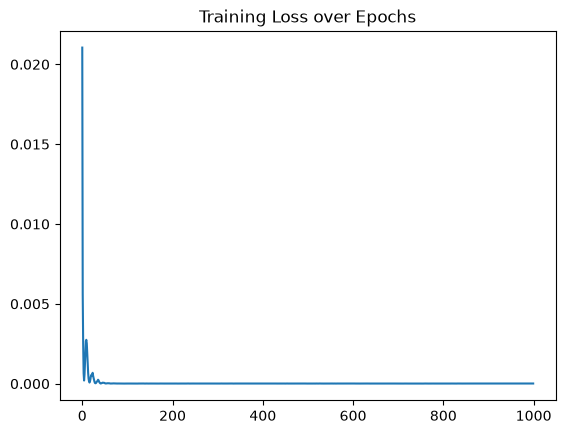

In [8]:
LOGGER.info("Training vector field models...")
v_model, omega_model, loss_list = train_vector_field_models(
    X_low, base_cometric, c_km, f_values_low, Lf_values_low, f_grad_values_low,m=cfg.m,n_epochs=1000
)
v_hat_deep_low = v_model(X_low).detach()
b_hat_deep_low = omega_model(X_low).detach()
plt.plot(loss_list)
plt.title("Training Loss over Epochs")
plt.show()

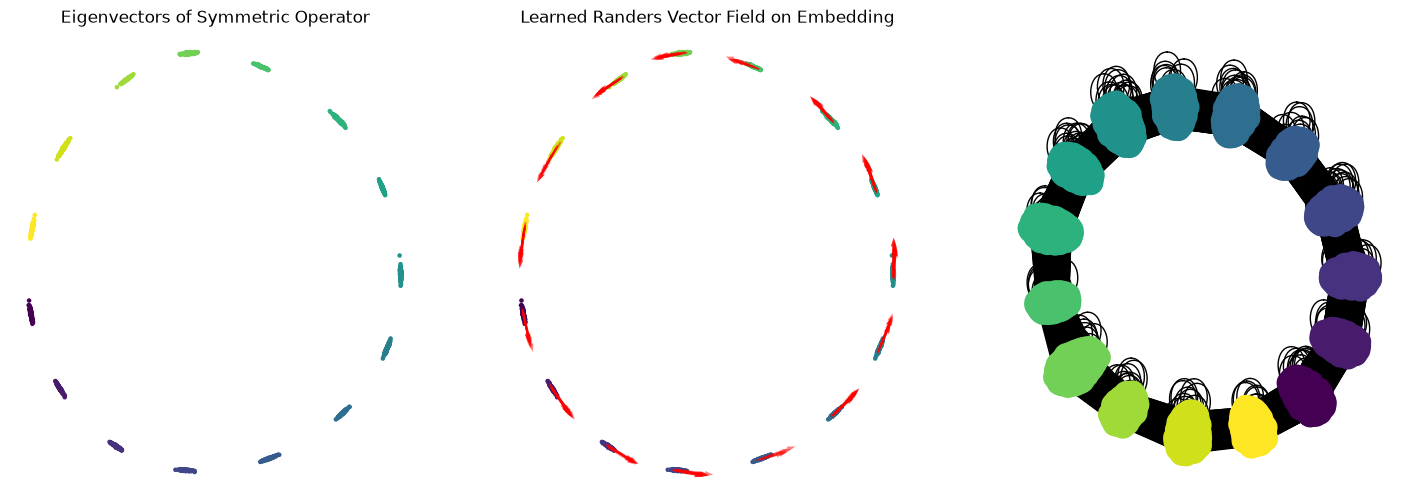

In [9]:
skip=10
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].scatter(X_low[:, 0].detach().cpu(), X_low[:, 1].detach().cpu(), c=community_labels, cmap="viridis", s=5)
axes[0].set_title("Eigenvectors of Symmetric Operator")
axes[1].scatter(X_low[:, 0].detach().cpu(), X_low[:, 1].detach().cpu(), c=community_labels, cmap="viridis", s=5)
axes[1].quiver(
    X_low[::skip, 0].detach().cpu(),
    X_low[::skip, 1].detach().cpu(),
    b_hat_deep_low[::skip, 0].detach().cpu(),
    b_hat_deep_low[::skip, 1].detach().cpu(),
    color="red",
    scale=0.2,
    alpha=0.5,
    angles="xy",
    scale_units="xy"
)
axes[1].set_title("Learned Randers Vector Field on Embedding")
nx.draw(graph, with_labels=False, node_color=community_labels.numpy(), cmap=plt.cm.viridis, ax=axes[2])
for ax in axes:
    ax.axis("off")

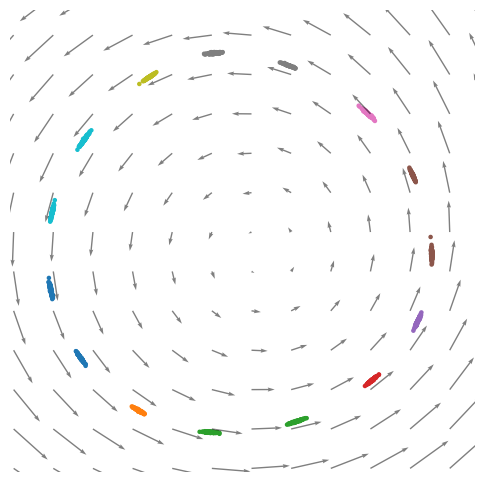

In [10]:
# Meshgrid for vector field visualization
bounds_grid = get_bounds(X_low,margin=0.4)
bounds_plts = get_bounds(X_low,margin=0.1)
x = torch.linspace(bounds_grid[0], bounds_grid[1], 20)
y = torch.linspace(bounds_grid[2], bounds_grid[3], 20)
X, Y = torch.meshgrid(x, y, indexing='ij')
grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1)
omega_grid = omega_model(grid_points).detach()
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X_low[:, 0].detach().cpu(), X_low[:, 1].detach().cpu(), c=community_labels, cmap="tab10", s=5)
ax.quiver(
    grid_points[:, 0].detach().cpu(),
    grid_points[:, 1].detach().cpu(),
    omega_grid[:, 0].detach().cpu(),
    omega_grid[:, 1].detach().cpu(),
    color="black",
    scale=0.2,
    alpha=0.5,
    angles="xy",
    scale_units="xy"
)
ax.axis("off")
ax.set_xlim(bounds_plts[0], bounds_plts[1])
ax.set_ylim(bounds_plts[2], bounds_plts[3])
plt.savefig("disbm_vector_field.pdf", dpi=300, bbox_inches='tight')